In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [9]:

import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

PyTorch version: 2.10.0
CUDA available: False


device(type='cpu')

In [10]:

def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [11]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

len(train_dataset), len(test_dataset)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 7.84MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 310kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.89MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 847kB/s]


(60000, 10000)

In [12]:

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])


In [17]:
images[1][0][0]

tensor([-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
        -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
        -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
        -0.4242, -0.4242, -0.4242, -0.4242])

In [18]:
import seaborn as sns

<Axes: >

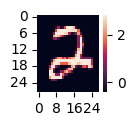

In [30]:
plt.figure(figsize=(1,1))

sns.heatmap(images[1][0])

In [34]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        # Input shape: [B, 1, 28, 28] => [Batch size, number of channels or features, pix height, pix width]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # Output after conv1: [B, 16, 28, 28]

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) #kernel size is the size of the patch you look at at a time 
        # Pool halves height and width

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # After conv2 (before pooling): [B, 32, 14, 14]
        # After second pool: [B, 32, 7, 7]

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        # Block 2
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, start_dim=1)

        # Classifier
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = SimpleCNN().to(device)
model

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [35]:

x = torch.randn(4, 1, 28, 28).to(device)

print("Input:         ", x.shape)

x = model.conv1(x)
print("After conv1:   ", x.shape)

x = F.relu(x)
x = model.pool(x)
print("After pool1:   ", x.shape)

x = model.conv2(x)
print("After conv2:   ", x.shape)

x = F.relu(x)
x = model.pool(x)
print("After pool2:   ", x.shape)

x = torch.flatten(x, start_dim=1)
print("After flatten: ", x.shape)

x = model.fc1(x)
print("After fc1:     ", x.shape)

x = model.fc2(F.relu(x))
print("After fc2:     ", x.shape)

Input:          torch.Size([4, 1, 28, 28])
After conv1:    torch.Size([4, 16, 28, 28])
After pool1:    torch.Size([4, 16, 14, 14])
After conv2:    torch.Size([4, 32, 14, 14])
After pool2:    torch.Size([4, 32, 7, 7])
After flatten:  torch.Size([4, 1568])
After fc1:      torch.Size([4, 128])
After fc2:      torch.Size([4, 10])


In [36]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [37]:

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [38]:

epochs = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
        f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}"
    )

Epoch 01/5 | Train loss: 0.1992 | Train acc: 0.9391 | Test loss: 0.0509 | Test acc: 0.9830
Epoch 02/5 | Train loss: 0.0680 | Train acc: 0.9794 | Test loss: 0.0363 | Test acc: 0.9869
Epoch 03/5 | Train loss: 0.0501 | Train acc: 0.9842 | Test loss: 0.0321 | Test acc: 0.9890
Epoch 04/5 | Train loss: 0.0392 | Train acc: 0.9876 | Test loss: 0.0303 | Test acc: 0.9899
Epoch 05/5 | Train loss: 0.0333 | Train acc: 0.9896 | Test loss: 0.0294 | Test acc: 0.9891


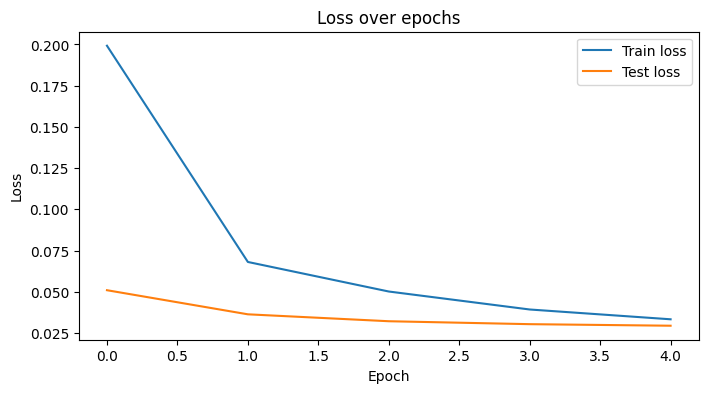

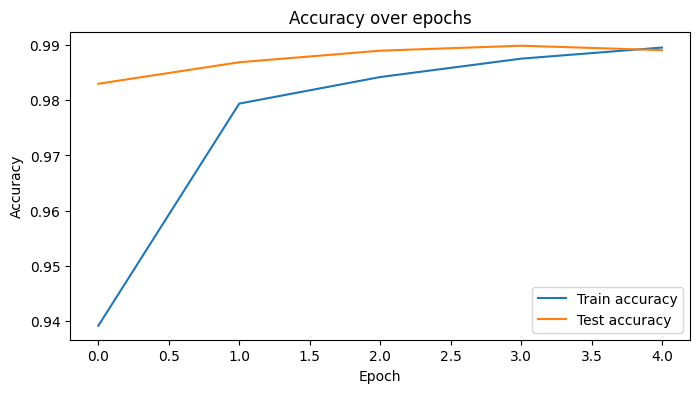

In [39]:

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="Train accuracy")
plt.plot(history["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.show()

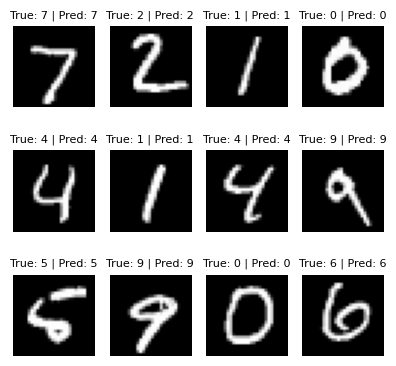

In [51]:

@torch.no_grad()
def get_predictions(model, loader, device, n=10):
    model.eval()
    images_all, labels_all, preds_all = [], [], []

    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu()

        images_all.append(images.cpu())
        labels_all.append(labels)
        preds_all.append(preds)

        if sum(len(x) for x in images_all) >= n:
            break

    images = torch.cat(images_all, dim=0)[:n]
    labels = torch.cat(labels_all, dim=0)[:n]
    preds = torch.cat(preds_all, dim=0)[:n]
    return images, labels, preds

sample_images, sample_labels, sample_preds = get_predictions(model, test_loader, device, n=12)

fig, axes = plt.subplots(3, 4, figsize=(4,4))
for ax, img, true_label, pred_label in zip(axes.flatten(), sample_images, sample_labels, sample_preds):
    ax.imshow(denormalize(img.squeeze(0)), cmap="gray")
    ax.set_title(f"True: {true_label.item()} | Pred: {pred_label.item()}", fontsize = 8)
    ax.axis("off")
plt.tight_layout()
plt.show()